# Análisis de metereología, bicicletas y tráfico por día.

Agregaremos los datos de bicicletas y trafico, que tenemos registradis hora a hora para anlizarlos a nivel dia. Los datos de meteroelogia ya estan a granularidad dia. En este paso se perdera la informacion sobre estaciones de bicicleta y sobre estaciones de medicion del trafico. De todas manera en este analisis esos datos no son nuetsro objetivo, Aqui queremos ver el comportamiento en conjunto de esta tres cosasa y como se comportan las variables todas juntas. tambien tenemos el calendario ya agregado a nivel dia, por lo que nuestro analisis tambien puede involucrar si el dia es laborable o no

### Requirements

In [1]:
# Importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Objetivo y pasos

En esta sección haremos una única matriz de correlaciones a nivel día entre el uso de BiciMad y el tráfico:
- Cargar los CSV limpios de bicis y tráfico.
- Normalizar nombres mínimos de columnas para usar `fecha` y la métrica de tráfico.
- Agregar por día con `groupby`.
- Unir ambos resultados y calcular la matriz de correlaciones.

In [2]:
# Configuración simple de display
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 50)

### Carga de datos limpios (bicis y tráfico)

Indicadme si las rutas son correctas o si preferís otras:
- BiciMad: `BiciMadrid/2022_bicimad_CleanData/2022_bicimad_cleaned.csv`
- Tráfico: `Trafico/2022_aforoTrafico_CleanData/trafico_madrid_2022_reestructurado.csv`

Ambos se cargarán con `read_csv` y luego normalizaremos las columnas clave.

In [3]:
# Cargar CSVs limpios
ruta_bicis = 'BiciMadrid/2022_bicimad_CleanData/2022_bicimad_cleaned.csv'
ruta_trafico = 'Trafico/2022_aforoTrafico_CleanData/trafico_madrid_2022_reestructurado.csv'

print('Cargando datos...')
df_bici = pd.read_csv(ruta_bicis)
df_traf = pd.read_csv(ruta_trafico)
print('Listo.')

print('\nBicis:', df_bici.shape, '| Trafico:', df_traf.shape)
print('Cols bicis:', list(df_bici.columns)[:12], '...')
print('Cols trafico:', list(df_traf.columns)[:12], '...')

Cargando datos...
Listo.

Bicis: (4073725, 5) | Trafico: (467280, 4)
Cols bicis: ['trip_minutes', 'unlock_station_name', 'lock_station_name', 'Dia', 'hora'] ...
Cols trafico: ['Dia', 'hora', 'estacion', 'afluencia'] ...
Listo.

Bicis: (4073725, 5) | Trafico: (467280, 4)
Cols bicis: ['trip_minutes', 'unlock_station_name', 'lock_station_name', 'Dia', 'hora'] ...
Cols trafico: ['Dia', 'hora', 'estacion', 'afluencia'] ...


### Agregación diaria de los datos de Bicis y Tráfico

Con estas agregaciones perdemos información acerca de la duración de los viajes en bici y de los nombres de estaciones de bicicletas y de medición de tráfico. Los dataframes resultantes tienen dos columnas: Una con la fecha, y otra con los recuentos de cada día.

- Bicis: contar viajes por día, esto es, el número de filas que tienen la misma fecha. La columna se llamará `num_viajes`
- Tráfico: sumar `afluencia` por día en la columna `intensidad_trafico_dia`. 

In [15]:
# Bicis: viajes por día
bicis_por_dia = df_bici.groupby('Dia').size().reset_index(name='num_viajes')

# Tráfico: afluencia por día
trafico_por_dia = df_traf.groupby('Dia')['afluencia'].sum().reset_index(name='afluencia_trafico')

print('Agregados listos:', bicis_por_dia.shape, trafico_por_dia.shape)

Agregados listos: (365, 2) (354, 2)


+ Recordemos que en el dataset de tráfico hay un intervalo de 11 días sin datos, por eso este dataset tiene unicamente 354 filas.

### Uniones con Meteo y Calendario (inner join)

Haremos un inner join por `Dia` para asegurar que solo se conserven los días presentes en todos los datasets:
- Bicis (num_viajes por día)
- Tráfico (afluencia_trafico por día)
- Meteo (tavg, prcp)
- Calendario (Tipo)

In [16]:
# Cargar Meteo (Dia, tavg, prcp) y Calendario (Dia, Tipo)
ruta_meteo = 'TiempoMetereologico/2022_meteostat_CleanData/meteo_madrid_2022_limpio.csv'
ruta_cal = 'CalendarioLaboral/calendario_clean.csv'

meteo = pd.read_csv(ruta_meteo)
meteo = meteo[['Dia','tavg','prcp']]

cal = pd.read_csv(ruta_cal, sep=';', encoding='latin1')
cal = cal[['Dia','Tipo']]

# Inner joins por Dia (conserva solo días comunes a todos)
master = bicis_por_dia.merge(trafico_por_dia, on='Dia', how='inner') \
                     .merge(meteo, on='Dia', how='inner') \
                     .merge(cal, on='Dia', how='inner')

print('Master final (inner join):', master.shape)
master.head()

Master final (inner join): (354, 6)


,Dia,num_viajes,afluencia_trafico,tavg,prcp,Tipo
0,2022-01-01,3992,1127282,10.1,0.0,Festivo
1,2022-01-02,4687,1265170,9.5,0.0,domingo
2,2022-01-03,6927,1894138,9.1,0.0,laborable
3,2022-01-04,5787,1957999,7.4,7.3,laborable
4,2022-01-05,4234,1967016,5.9,5.0,laborable


### Etiquetado de la columna de tipos de día.

En esta sección creamos una codificación numérica de la columna `Tipo` para facilitar análisis cuantitativos:

- laborable → 0
- sabado → 1
- domingo o festivo → 2

Criterio: el valor refleja el impacto esperado en la actividad laboral de las personas (laborable con mayor actividad, sábado intermedio, domingo/festivo con menor actividad).

In [17]:
# Codificación numérica de 'Tipo' según impacto laboral
# laborable=0, sabado=1, domingo/festivo=2
import pandas as pd

mapeo_tipo = {
    'laborable': 0,
    'sabado': 1,
    'sábado': 1,
    'domingo': 2,
    'festivo': 2
}

# Asegurar texto en minúsculas para mapear de forma robusta
master['tipo_numerico'] = (
    master['Tipo']
      .astype(str)
      .str.lower()
      .map(mapeo_tipo)
)

print('Columnas disponibles:', list(master.columns))
print('Resumen tipo_numerico:')
print(master['tipo_numerico'].value_counts(dropna=False))
master.head()

Columnas disponibles: ['Dia', 'num_viajes', 'afluencia_trafico', 'tavg', 'prcp', 'Tipo', 'tipo_numerico']
Resumen tipo_numerico:
tipo_numerico
0    242
2     62
1     50
Name: count, dtype: int64


,Dia,num_viajes,afluencia_trafico,tavg,prcp,Tipo,tipo_numerico
0,2022-01-01,3992,1127282,10.1,0.0,Festivo,2
1,2022-01-02,4687,1265170,9.5,0.0,domingo,2
2,2022-01-03,6927,1894138,9.1,0.0,laborable,0
3,2022-01-04,5787,1957999,7.4,7.3,laborable,0
4,2022-01-05,4234,1967016,5.9,5.0,laborable,0


## Análisis de Correlaciones.

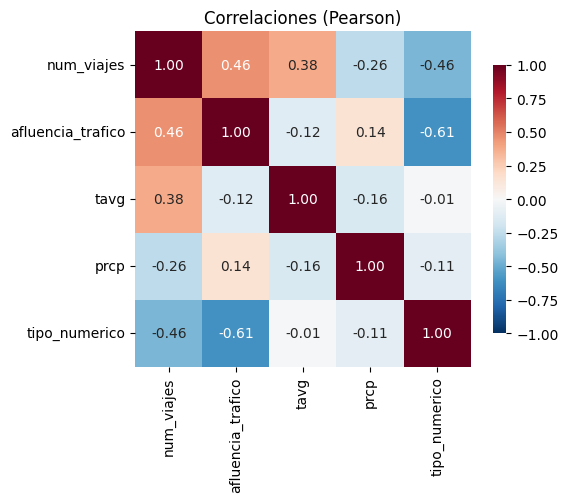

In [21]:
# Análisis de Correlaciones
columnas = ['num_viajes', 'afluencia_trafico', 'tavg', 'prcp', 'tipo_numerico']

df_corr = master[columnas].corr(method='pearson')

plt.figure(figsize=(6, 5))
sns.heatmap(df_corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Correlaciones (Pearson)')
plt.tight_layout()
plt.show()

### Insights

- La meteorología diaria influye significativamente en el uso de la bicicleta y en el tráfico rodado. Este efecto es más pronunciado en el caso de las bicicletas: la correlación entre el número de viajes y la temperatura media es positiva (0,38), mientras que con la precipitación es negativa (-0,26). En el tráfico, la temperatura muestra una correlación negativa (-0,12) y la precipitación una positiva (0,14).

- El tipo de día (laborable, sábado, domingo/festivo) tiene un impacto claro en la movilidad: tanto los viajes en bicicleta (-0,46) como el tráfico (-0,61) disminuyen en fines de semana y festivos, reflejando la menor actividad laboral.

- Existe una relación directa entre el uso de la bicicleta y el tráfico (correlación 0,46), lo que sugiere que ambos modos de transporte responden a patrones comunes de movilidad diaria.

En resumen, los resultados confirman que los días no laborables y las condiciones meteorológicas adversas (lluvia, bajas temperaturas) reducen la movilidad tanto en bicicleta como en vehículo privado, mientras que las temperaturas más altas favorecen el uso de la bicicleta y disminuyen el tráfico motorizado.